In [75]:
# Import libraries and read the dataset

In [76]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import style
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import *
from pylab import rcParams
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter

In [77]:
import warnings
warnings.filterwarnings('ignore') # To ignore some of seaborn warning msg

In [78]:
%matplotlib inline
rcParams['figure.figsize'] = 5, 4
sns.set_style('whitegrid')
# Laod the dataset
df = pd.read_csv('kc_house_data.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [79]:
# Explore the data and check some important stats
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [80]:
# Observing that bedroom columns has 0 and 33 , the dataset has houses where house has 33 bedrooms and 0 as well.
# Square feet ranges 13,450 to 290. 
# This shows that the data is well distributed.
# Similarly , we can infer so many things by just looking at the describe function.
# Lets see some visualization and also going to see how and what can we infer from visualization.

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [82]:
df.shape

(21613, 21)

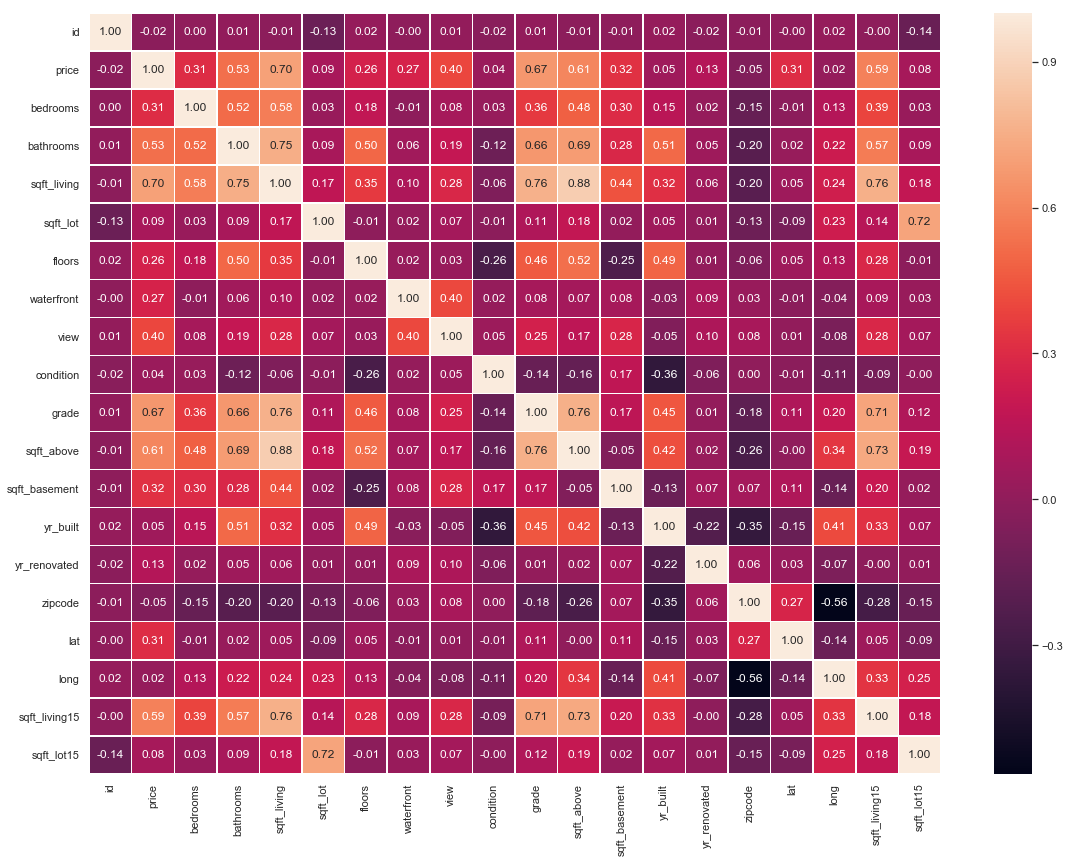

In [83]:
#df correlation matrix shows relations between all variables in the dataset  
f,ax = plt.subplots(figsize=(17, 14))
sns.heatmap(df.corr(), annot=True,annot_kws={'size': 12}, linewidths=.5, fmt='.2f', ax=ax)

In [84]:
# Getting insight of data using scatter plot (Feature vs Price)

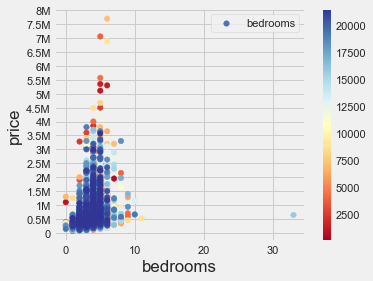

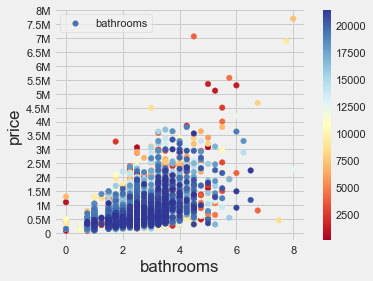

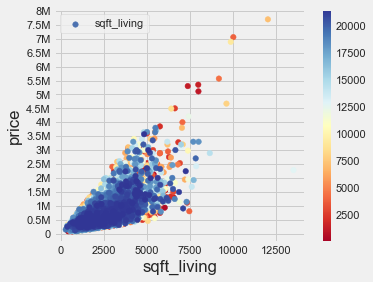

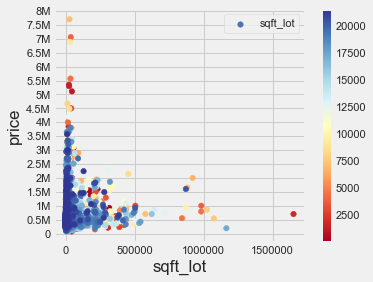

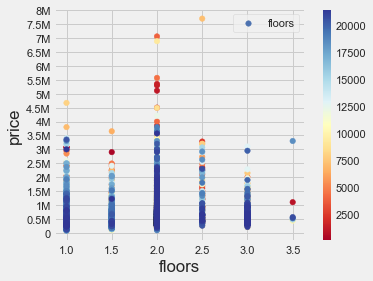

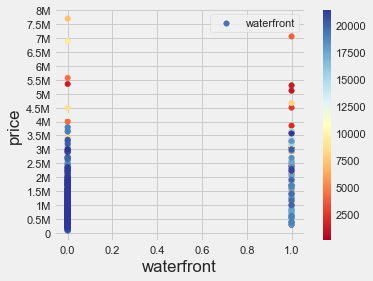

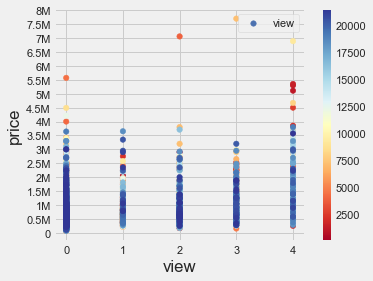

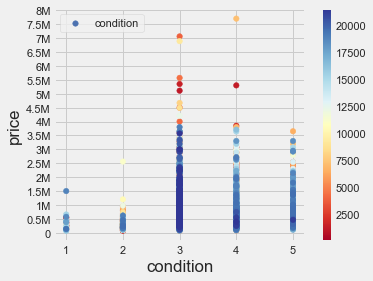

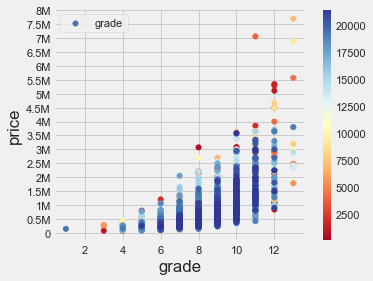

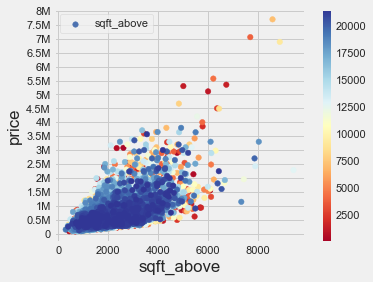

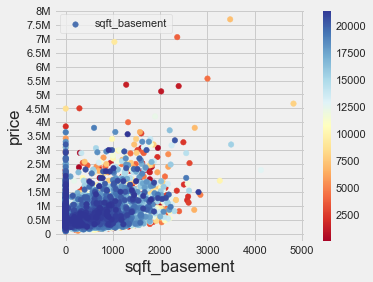

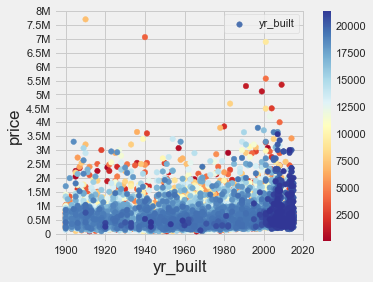

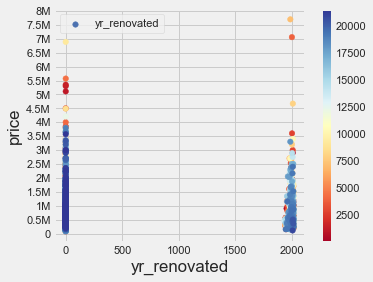

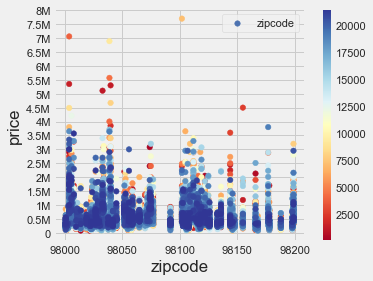

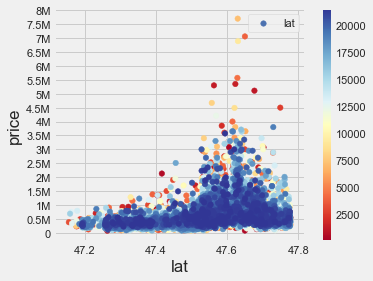

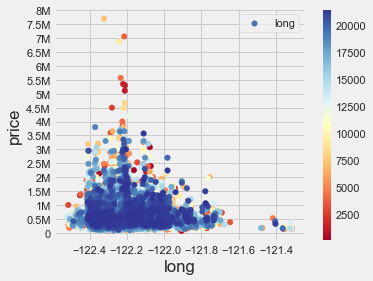

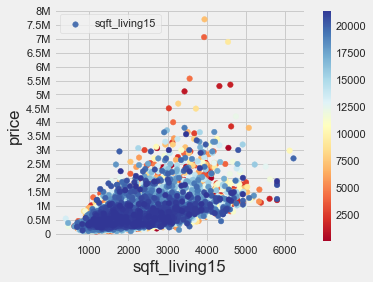

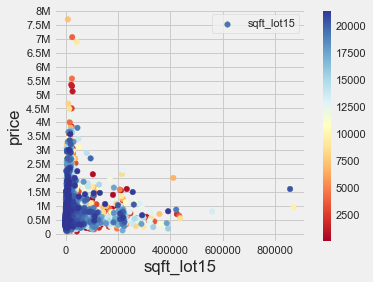

In [85]:
features = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15']
feature_matrix = df[features]
#feature_matrix = preprocessing.scale(feature_matrix)
feature_matrix_unscaled = df[features]
lable_vector = df['price']
feature_matrix_unscaled.head()
style.use('fivethirtyeight')
cm = plt.cm.get_cmap('RdYlBu')
xy = range(1,21614)
z = xy
for feature in feature_matrix_unscaled:
    sc = plt.scatter(df[feature], df['price'], label = feature, c = z, marker = 'o', s = 30, cmap = cm)
    plt.colorbar(sc)
    plt.xlabel(''+feature)
    plt.ylabel('price')
    plt.yticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M',])
    plt.legend()
    plt.show()

In [86]:
# Lets select the main variable (important features) and review the insigts by using pairplots 

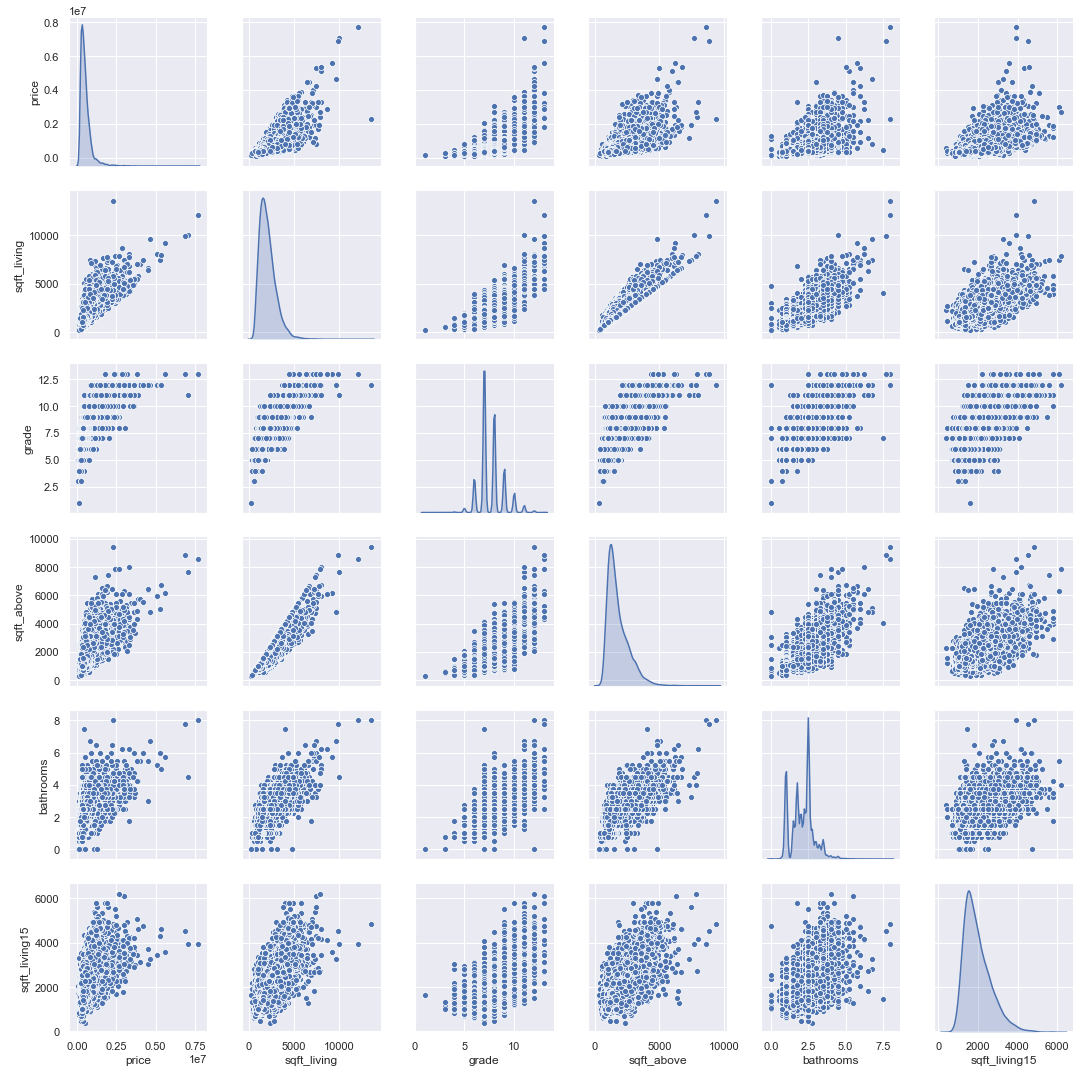

In [87]:
sns.set()
cols = df[['price','sqft_living','grade','sqft_above','bathrooms','sqft_living15']]
sns.pairplot(cols, size = 2.5,diag_kind='kde')

In [88]:
# Linear regression

In [89]:
my_linear = LinearRegression()

In [90]:
my_linear.fit(feature_matrix, lable_vector)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [91]:

# printing Theta0 using attribute "intercept_":
print(my_linear.intercept_)

# printing [Theta1, Theta2, Theta3] using attribute "coef_":
print(my_linear.coef_)
coef_list = my_linear.coef_
# coef_list.sort()
print(coef_list)

6676741.097585369
[-3.57977853e+04  4.11667610e+04  1.10513887e+02  1.28404250e-01
  6.69515754e+03  5.83016948e+05  5.29340750e+04  2.64129543e+04
  9.59857923e+04  7.08271265e+01  3.96867610e+01 -2.62241050e+03
  1.98241805e+01 -5.82571668e+02  6.02825208e+05 -2.14960624e+05
  2.16758491e+01 -3.82461030e-01]
[-3.57977853e+04  4.11667610e+04  1.10513887e+02  1.28404250e-01
  6.69515754e+03  5.83016948e+05  5.29340750e+04  2.64129543e+04
  9.59857923e+04  7.08271265e+01  3.96867610e+01 -2.62241050e+03
  1.98241805e+01 -5.82571668e+02  6.02825208e+05 -2.14960624e+05
  2.16758491e+01 -3.82461030e-01]


In [92]:
# Sorting features based on co-efficient values from linear regression.

In [93]:
feature_dict = dict(zip(features, coef_list))
#print(feature_dict)
import operator
sorted_d = sorted(feature_dict.items(), key=operator.itemgetter(1),reverse=True)
print('Dictionary in descending order by value : ',sorted_d)

Dictionary in descending order by value :  [('lat', 602825.208090825), ('waterfront', 583016.9475138097), ('grade', 95985.79230520976), ('view', 52934.07499961991), ('bathrooms', 41166.76100980492), ('condition', 26412.95433473437), ('floors', 6695.157538718477), ('sqft_living', 110.51388747537683), ('sqft_above', 70.82712645273483), ('sqft_basement', 39.68676098856542), ('sqft_living15', 21.675849068180238), ('yr_renovated', 19.824180497892005), ('sqft_lot', 0.12840424994247993), ('sqft_lot15', -0.3824610303938751), ('zipcode', -582.5716677591757), ('yr_built', -2622.410499457506), ('bedrooms', -35797.78526877543), ('long', -214960.62365186532)]


In [94]:
# Checking best features vs price using pairplot

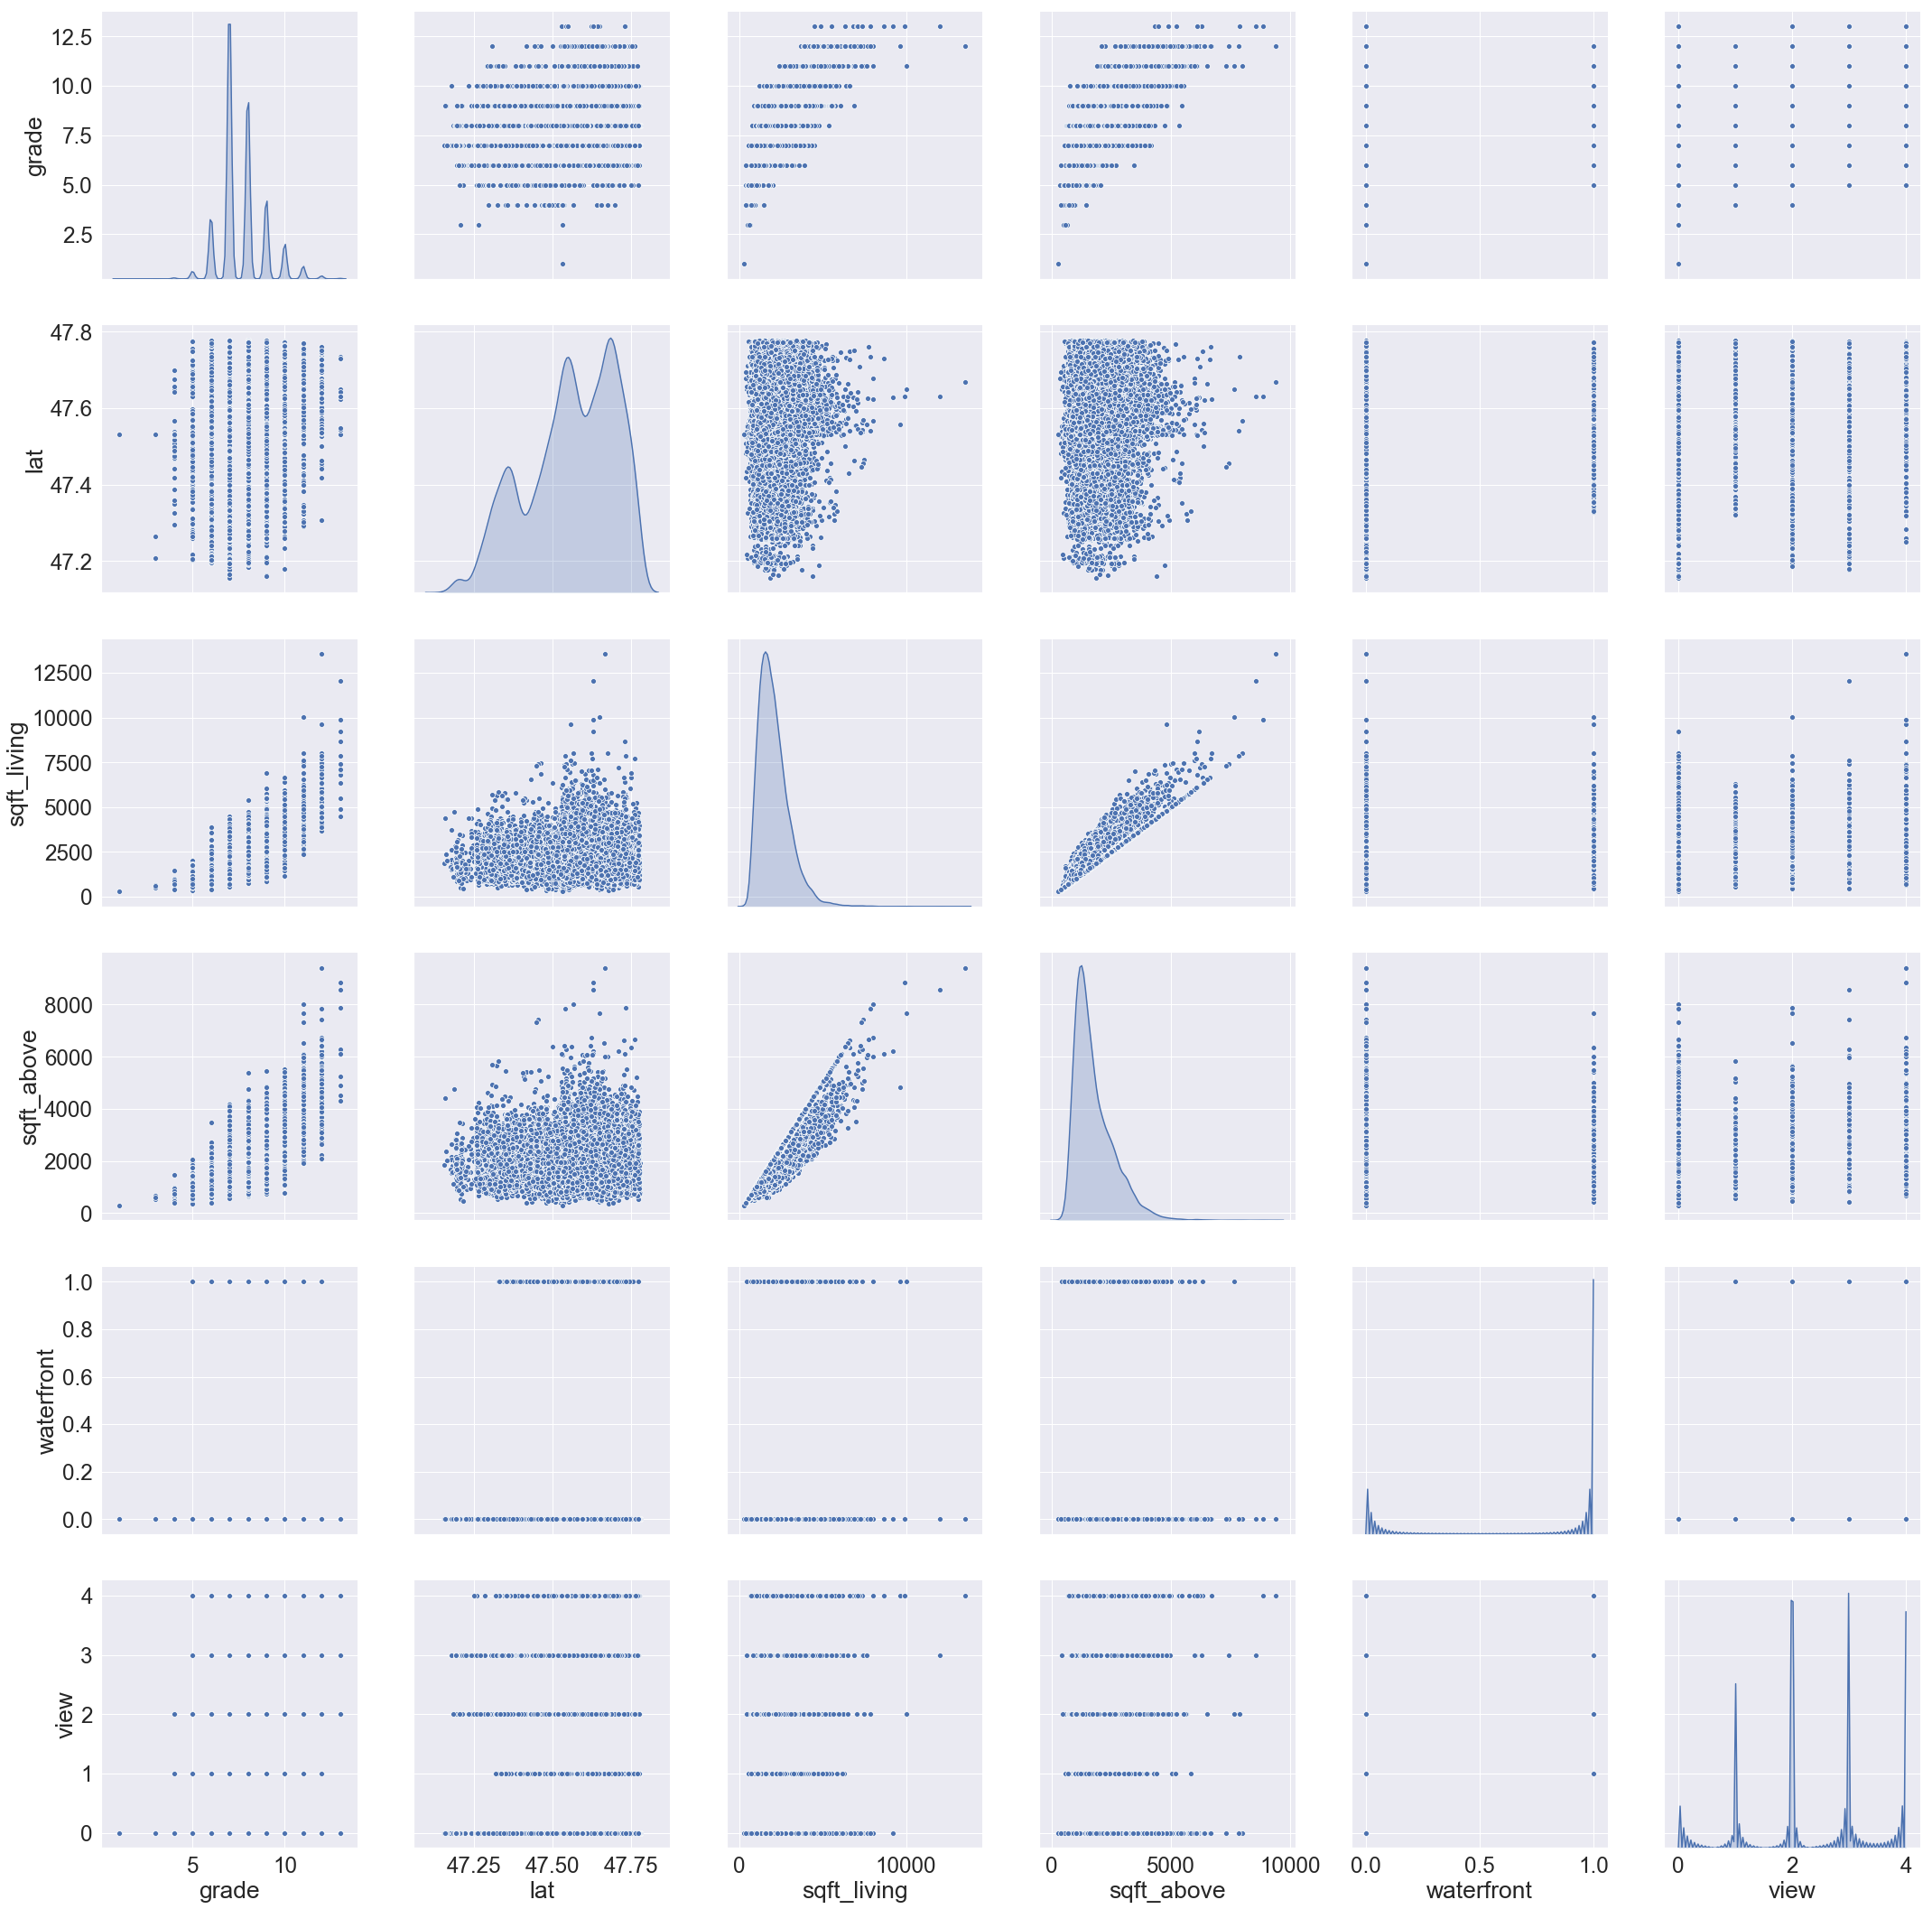

In [95]:
## Pairplot
##Scatterplot
sorted_features = ['grade','lat','sqft_living','sqft_above','waterfront','view']
sns.set(font_scale=2.2)
g = sns.pairplot(df[sorted_features] ,size=5,diag_kind='kde')
plt.show()


In [96]:

#sorting best features based on co-efficient values.
#sorted_features = ['sqft_living','sqft_basement','sqft_above','sqft_lot','yr_built','bedrooms']
#sorted_features = ['lat','waterfront','grade','view','bathrooms','condition'] # all features without scale
sorted_features = ['grade','lat','sqft_living','sqft_above','waterfront','view']
best_feature_matrix = df[sorted_features]
#scaling deature
#best_feature_matrix = preprocessing.scale(best_feature_matrix)

X_train, X_test, y_train, y_test = train_test_split(best_feature_matrix, lable_vector, test_size=0.3, random_state=3)
my_linear.fit(X_train, y_train)
y_predict_ln = my_linear.predict(X_test)
print(y_predict_ln)

[ 603725.46358679 1101543.8425091   833863.07247597 ...  205274.75703483
  364476.35466848  356596.25643819]


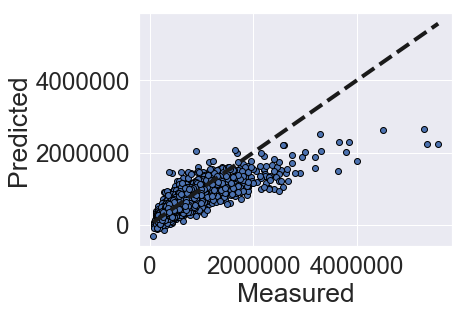

In [97]:
y_predict_ln = my_linear.predict(X_test)
fig, ax = plt.subplots()
ax.scatter(y_test, y_predict_ln, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

In [98]:
error = mean_squared_error(y_test, y_predict_ln)
root_mean_square_error = np.sqrt(error)
print("RMSE for liner regression>>>",root_mean_square_error)

RMSE for liner regression>>> 213247.14656738812


In [99]:
# KNN

In [100]:
k = 25
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_predict_knn = knn.predict(X_test)
score_knn = accuracy_score(y_test, y_predict_knn)
print("KNN accuracy>>>>",score_knn)

KNN accuracy>>>> 0.0053979025293029


In [101]:
# Decision Tree

In [102]:
my_decisiontree = DecisionTreeClassifier()
my_decisiontree.fit(X_train, y_train)
y_predict_dt = my_decisiontree.predict(X_test)
score_dt= accuracy_score(y_test, y_predict_dt)
print("Decision tree accuracy>>>>",score_dt)

Decision tree accuracy>>>> 0.008482418260333127


In [103]:
# Cross Validation

In [104]:
kc_linear_reg = LinearRegression()
new_feature_marrix = preprocessing.scale(feature_matrix)
kc_mse = cross_val_score(kc_linear_reg,new_feature_marrix,lable_vector, cv=10, scoring='neg_mean_squared_error')


house_mse_positive = -kc_mse

house_rmse = np.sqrt(house_mse_positive)

print("RMSE for cross validation>>>",house_rmse.mean())

RMSE for cross validation>>> 202158.75728839115


In [105]:
# Random Forest

In [106]:
my_RandomForest = RandomForestClassifier(n_estimators = 10, bootstrap = True, random_state=2)
my_RandomForest.fit(X_train,y_train) #train random forest classifier using training data
y_predict_rf=my_RandomForest.predict(X_test) #predict using testing data
score_rf=accuracy_score(y_test, y_predict_rf) #accuracy based on predicted values and original values
print("Accuracy for Random Forest>>>>> ",score_rf)

Accuracy for Random Forest>>>>>  0.00987045033929673


In [107]:
# P C A

In [108]:
n=6
my_pca = PCA(n_components=n)
feature_matrix_scaled = preprocessing.scale(feature_matrix)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(feature_matrix_scaled, lable_vector, test_size=0.3, random_state=3)

In [109]:
X_Train_new = my_pca.fit_transform(X_train_pca)
X_Test_new = my_pca.transform(X_test_pca)
print(X_Test_new.shape)
my_linear = LinearRegression()

(6484, 6)


In [110]:
my_linear.fit(X_Train_new, y_train_pca)
y_predict_ln = my_linear.predict(X_Test_new)#score_lr = accuracy_score(y_test, y_predict_ln)
error = mean_squared_error(y_test_pca, y_predict_ln) 
root_mean_square_error = np.sqrt(error) 
print("RMSE for PCA>>>>>>>",root_mean_square_error)

RMSE for PCA>>>>>>> 230859.01115900133


In [111]:
# Coefficient of determination

In [112]:
df['year_sell'] = [int(i[:4]) for i in df.date]

df.year_sell.value_counts().sort_index()


#test=kc_df[kc_df.year_sell==2015].reset_index(drop=True )
train=df[df.year_sell==2014].reset_index(drop=True )
x=train[df.columns.drop(['price','id','date'])]
y=train['price']
col=df.columns.drop(['price','id','date'])
clf = LinearRegression()
clf.fit(x,y)
score_dt = clf.score(x,y)
print("Determination>>>>>>",score_dt)

Determination>>>>>> 0.7072125653629924


In [113]:
# Adding features by taking square of each feature.

In [114]:
df_kc_square = pd.DataFrame()
for feature in features:
    df_kc_square[feature + '_square'] = df[feature]*df[feature]
print(df_kc_square.shape)

(21613, 18)


In [115]:
square_df = pd.concat([feature_matrix_unscaled, df_kc_square], axis=1)
square_df.shape

(21613, 36)

In [116]:

#normalize data
scaled_square_df = preprocessing.scale(square_df)

In [117]:
# PCA on squared data

In [118]:
n=7
my_pca = PCA(n_components=n)
X_train_square, X_test_square, y_train_square, y_test_square = train_test_split(scaled_square_df, lable_vector, test_size=0.3, random_state=3)

In [119]:

X_Train_new = my_pca.fit_transform(X_train_square)
X_Test_new = my_pca.transform(X_test_square)
my_linear_squared = LinearRegression()

In [120]:
my_linear_squared.fit(X_Train_new, y_train_square)
y_predict_sq = my_linear_squared.predict(X_Test_new)#score_lr = accuracy_score(y_test, y_predict_ln)
error = mean_squared_error(y_test_square, y_predict_sq) 
root_mean_square_error = np.sqrt(error) 
print("RMSE for squared PCA>>>>>>>",root_mean_square_error)

RMSE for squared PCA>>>>>>> 204245.19672840994


In [121]:
# Cross validation on squared data¶

In [122]:
kc_linear_reg_square = LinearRegression()
kc_mse = cross_val_score(kc_linear_reg,scaled_square_df,lable_vector, cv=10, scoring='neg_mean_squared_error')


house_mse_positive = -kc_mse

house_rmse = np.sqrt(house_mse_positive)

print("RMSE for squared cross validation>>>",house_rmse.mean())

RMSE for squared cross validation>>> 187784.55087439556


In [123]:
# Polynomial Regression

In [124]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)
#print(X_train_poly.shape)
poly_lin_reg = LinearRegression()
poly_lin_reg.fit(X_train_poly, y_train)
y_predict_poly = poly_lin_reg.predict(X_test_poly)
print(y_predict_poly)

[ 542123.89930725 1150053.24802971  813492.3820982  ...  285295.23047161
  288106.9879694   360325.07946491]


In [125]:
# error = mean_squared_error(y_predict_poly, y_test)
#print(error)
root_mean_square_error = np.sqrt(error)
print("RMSE for polynomial regression>>>>>>>>",root_mean_square_error)

RMSE for polynomial regression>>>>>>>> 204245.19672840994


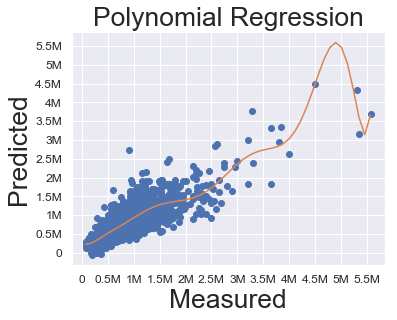

In [126]:
z = np.polyfit(y_test,y_predict_poly,10) 

p = np.poly1d(z)

plt.title ('Polynomial Regression')
plt.xlabel('Measured')
plt.ylabel('Predicted')
plt.yticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M'], fontsize = 12)
plt.xticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M'], fontsize = 12)
    

#plt.plot(y_test[:100], y_predict_poly[:100],'o-')
#plt.plot(y_test[:5], y_predict_poly[:5], '-')

datax_os = np.linspace(y_test.min(), y_test.max(), 50)
#plt.figure(figsize=(18,18))
plt.plot(y_test, y_predict_poly, 'o',datax_os, p(datax_os) ) # 'smoother' line

plt.show()


In [127]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_Train_new, y_train_square)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
           oob_score=False, random_state=42, verbose=0, warm_start=False)

In [128]:
housing_predictions = forest_reg.predict(X_Train_new)
forest_mse = mean_squared_error( y_train_square, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

76585.67113475346

In [129]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
forest_scores = cross_val_score(forest_reg,X_Train_new,y_train_square,
                             scoring="neg_mean_squared_error", cv=5)
tree_rmse_scores = np.sqrt(-forest_scores)
display_scores(tree_rmse_scores)

Scores: [185434.70931363 187966.48381739 187292.20845525 195200.06336991
 182911.76191382]
Mean: 187761.04537399902
Standard deviation: 4111.651524552817


In [130]:
from sklearn.model_selection import GridSearchCV

In [131]:
param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10]},
  ]

In [132]:
forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg,param_grid, cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_Train_new,y_train_square)

GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
           oob_score=False, random_state=42, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid=[{'n_estimators': [3, 10, 30]}, {'bootstrap': [False], 'n_estimators': [3, 10]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='neg_mean_squared_error', verbose=0)

In [133]:
grid_search.best_params_
          
grid_search.best_estimator_
          
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

209793.9637706879 {'n_estimators': 3}
187806.37839812884 {'n_estimators': 10}
184215.25827610606 {'n_estimators': 30}
240513.72333604613 {'bootstrap': False, 'n_estimators': 3}
239832.40824037624 {'bootstrap': False, 'n_estimators': 10}


In [134]:
final_model = grid_search.best_estimator_ 

In [135]:
# Standardizing makes our data distributed normal and it is very usefull for a good prediction
final_predictions = final_model.predict(X_Test_new)

In [136]:
final_mse = mean_squared_error(y_test_square, final_predictions)
final_rmse = np.sqrt(final_mse)
          
final_rmse

173927.33194734895

In [137]:
# RMSE for polynomial regression>>>>>>>> 204103.27627473456
# Accuracy results of KNN, Decision Tree Classifier also shared
# RMSE based on Gridsearch 182701.64202139986 {'n_estimators': 30}
# Cross Validation with Linear Regression.RMSE for squared cross validation>>> 188694.12653724116 
# Random Forest Regressor with Grid Search best estimator gives a result of 173471.865131301
# RandomForestRegressor has the least RMSE>>>>>76163.08940396484 (after PCA)

In [138]:
# Out of linear regression models go with CV and along-side Random Forest Regressor